# FlexOn — Experiments

This notebook is the **benchmark and analysis layer** of the project.

It runs the six core execution modes against the frozen `flexon_online` runtime:

| Case | Resource selection | Adaptive level | Recovery |
|---|---|---:|---:|
| Fixed CPU | CPU | No | No |
| Fixed CUDA | CUDA | No | No |
| Dynamic | Auto | No | No |
| Dynamic + Adaptive | Auto | Yes | No |
| Dynamic + Recovery | Auto | No | Yes |
| Dynamic + Adaptive + Recovery | Auto | Yes | Yes |

This notebook deliberately has **no contention API**. If contention is desired, start it independently from `contention_generator.ipynb`; the same benchmark code then measures the stressed environment.

## Experimental principle

The separation is intentional:

- `experiments.contention` controls the machine environment.
- `experiments.runner` invokes and parses FlexOn.
- `experiments.measurements` computes latency statistics.
- `experiments.analysis` builds comparable dataframes.
- `experiments.plotting` produces research figures.

Therefore the six cases below are identical with or without contention.

In [33]:
from pathlib import Path
import sys
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "experiments").is_dir():
    PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

modules_to_clear = [name for name in sys.modules if name.startswith("experiments")]
for mod in modules_to_clear:
    del sys.modules[mod]

from experiments.config import ExperimentConfig, RunConfig
from experiments.runner import run_online
from experiments.measurements import measure_run
from experiments.analysis import (
    ExperimentRecord,
    run_summary_dataframe,
    latency_samples_dataframe,
    summarize_latency,
    compare_latency,
    runtime_diagnostics_dataframe,
)
from experiments.plotting import (
    plot_latency_comparison,
    plot_tail_latency,
    plot_latency_distribution,
    plot_latency_percentiles,
    plot_resource_execution_breakdown,
    plot_level_changes,
)

print(f"Project root: {PROJECT_ROOT}")


Project root: /home/aditya/Coding_23CSB0B30/Personal-Projects/FlexOn


## Benchmark configuration

Start with a moderate benchmark while validating the pipeline. Once the experiment is stable, increase repetitions if the contention environment is noisy.

The runtime's unconditional `[scheduler] iteration measured_ms=...` record is the authoritative end-to-end iteration latency. Warmups are removed positionally.

In [34]:
EXPERIMENT = ExperimentConfig(
    warmup_iterations=10,
    measured_iterations=100,
    repetitions=5,
    timeout_seconds=300,
)

ARTIFACT = PROJECT_ROOT / "artifacts" / "efficientnet_lite4"
ONLINE_BINARY = PROJECT_ROOT / "apps" / "flexon_online"
SCHEDULER_CONFIG = PROJECT_ROOT / "config" / "scheduler.yaml"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Set this manually for result bookkeeping. It does NOT start or control contention.
# Examples: "no_contention", "cpu-25gpu-25", "cpu50gpu50".
ENVIRONMENT_LABEL = "cpu-25gpu-25"

# Protect FlexOn scheduler/control logic while keeping inference at normal CPU
# scheduling priority. Requires the one-time setup of the privileged scheduler helper.
PRIORITY_ISOLATION = True
(RESULTS_DIR / ENVIRONMENT_LABEL).mkdir(parents=True, exist_ok=True)

if not ONLINE_BINARY.exists():
    raise FileNotFoundError(f"Online binary not found: {ONLINE_BINARY}")
if not ARTIFACT.exists():
    raise FileNotFoundError(f"Artifact not found: {ARTIFACT}")

print("artifact:", ARTIFACT)
print("binary:", ONLINE_BINARY)
print("warmup:", EXPERIMENT.warmup_iterations)
print("measured:", EXPERIMENT.measured_iterations)
print("repetitions:", EXPERIMENT.repetitions)

artifact: /home/aditya/Coding_23CSB0B30/Personal-Projects/FlexOn/artifacts/efficientnet_lite4
binary: /home/aditya/Coding_23CSB0B30/Personal-Projects/FlexOn/apps/flexon_online
warmup: 10
measured: 100
repetitions: 5


### Priority-isolated execution

When `PRIORITY_ISOLATION` is enabled, the experiment runner launches `flexon_online` through `apps/flexon_online`. The launcher starts `flexon_online` normally, waits for CUDA/ONNX Runtime initialization to complete, then promotes the already-running control thread to `SCHED_FIFO` at the maximum Linux real-time priority. The runtime demotes actual inference execution to normal priority.


## Define the six benchmark cases

These are the only execution-policy dimensions varied in the core experiment matrix. Contention is an external environment and is therefore not encoded here.

In [35]:
CASES = {
    "fixed_cpu": RunConfig(
        artifact=ARTIFACT,
        iterations=EXPERIMENT.warmup_iterations + EXPERIMENT.measured_iterations,
        level=0,
        resource="cpu",
        scheduler_config=SCHEDULER_CONFIG,
    ),

    "fixed_cuda": RunConfig(
        artifact=ARTIFACT,
        iterations=EXPERIMENT.warmup_iterations + EXPERIMENT.measured_iterations,
        level=0,
        resource="cuda",
        scheduler_config=SCHEDULER_CONFIG,
    ),

    "dynamic": RunConfig(
        priority_isolation=PRIORITY_ISOLATION,
        artifact=ARTIFACT,
        iterations=EXPERIMENT.warmup_iterations + EXPERIMENT.measured_iterations,
        resource="auto",
        scheduler_config=SCHEDULER_CONFIG,
    ),

    "dynamic_adaptive": RunConfig(
        priority_isolation=PRIORITY_ISOLATION,
        artifact=ARTIFACT,
        iterations=EXPERIMENT.warmup_iterations + EXPERIMENT.measured_iterations,
        resource="auto",
        adaptive_level=True,
        scheduler_config=SCHEDULER_CONFIG,
    ),

    "dynamic_recovery": RunConfig(
        priority_isolation=PRIORITY_ISOLATION,
        artifact=ARTIFACT,
        iterations=EXPERIMENT.warmup_iterations + EXPERIMENT.measured_iterations,
        resource="auto",
        recovery=True,
        scheduler_config=SCHEDULER_CONFIG,
    ),

    "dynamic_adaptive_recovery": RunConfig(
        priority_isolation=PRIORITY_ISOLATION,
        artifact=ARTIFACT,
        iterations=EXPERIMENT.warmup_iterations + EXPERIMENT.measured_iterations,
        resource="auto",
        adaptive_level=True,
        recovery=True,
        scheduler_config=SCHEDULER_CONFIG,
    ),
}

for name, config in CASES.items():
    print(name, "->", " ".join(config.command(ONLINE_BINARY)))

fixed_cpu -> /home/aditya/Coding_23CSB0B30/Personal-Projects/FlexOn/apps/flexon_online --artifact /home/aditya/Coding_23CSB0B30/Personal-Projects/FlexOn/artifacts/efficientnet_lite4 --iterations 110 --resource cpu --scheduler-config /home/aditya/Coding_23CSB0B30/Personal-Projects/FlexOn/config/scheduler.yaml --level 0
fixed_cuda -> /home/aditya/Coding_23CSB0B30/Personal-Projects/FlexOn/apps/flexon_online --artifact /home/aditya/Coding_23CSB0B30/Personal-Projects/FlexOn/artifacts/efficientnet_lite4 --iterations 110 --resource cuda --scheduler-config /home/aditya/Coding_23CSB0B30/Personal-Projects/FlexOn/config/scheduler.yaml --level 0
dynamic -> /home/aditya/Coding_23CSB0B30/Personal-Projects/FlexOn/apps/flexon_online --artifact /home/aditya/Coding_23CSB0B30/Personal-Projects/FlexOn/artifacts/efficientnet_lite4 --iterations 110 --resource auto --scheduler-config /home/aditya/Coding_23CSB0B30/Personal-Projects/FlexOn/config/scheduler.yaml --priority-isolation
dynamic_adaptive -> /home/ad

## Experiment runner

Each repetition is one independent invocation of `flexon_online`. The parser remains isolated from the subprocess call, and measurement uses the authoritative iteration-level timing.

In [36]:
def run_case(name: str, config: RunConfig) -> list[ExperimentRecord]:
    records = []
    for repetition in range(1, EXPERIMENT.repetitions + 1):
        run = run_online(
            config,
            binary=ONLINE_BINARY,
            timeout=EXPERIMENT.timeout_seconds,
            cwd=PROJECT_ROOT,
        )
        if not run.success:
            raise RuntimeError(
                f"{name} repetition {repetition} failed: {run.error or run.stderr}"
            )

        measurements = measure_run(
            run,
            warmup_iterations=EXPERIMENT.warmup_iterations,
        )
        records.append(
            ExperimentRecord(
                experiment=name,
                repetition=repetition,
                measurements=measurements,
                metadata={
                    "environment": ENVIRONMENT_LABEL,
                    "artifact": str(ARTIFACT),
                    "resource": config.resource,
                    "adaptive_level": config.adaptive_level,
                    "recovery": config.recovery,
                    "priority_isolation": config.priority_isolation,
                },
            )
        )
        print(
            f"{name}: repetition {repetition}/{EXPERIMENT.repetitions} "
            f"mean={measurements.latency.mean_ms:.3f} ms "
            f"p95={measurements.latency.p95_ms:.3f} ms"
        )
    return records


def run_all_cases():
    all_records = []
    for name, config in CASES.items():
        all_records.extend(run_case(name, config))
        print("-" * 100)
    return all_records

## Run the six cases

> **If using contention:** start the desired contention session in `contention_generator.ipynb` before executing this cell.

> **Without contention:** simply execute this cell with the contention session stopped.

In [49]:
records = run_all_cases()
print(f"Collected {len(records)} measured repetitions")

fixed_cpu: repetition 1/5 mean=21.875 ms p95=25.416 ms
fixed_cpu: repetition 2/5 mean=21.583 ms p95=24.818 ms
fixed_cpu: repetition 3/5 mean=20.941 ms p95=24.026 ms
fixed_cpu: repetition 4/5 mean=20.722 ms p95=25.050 ms
fixed_cpu: repetition 5/5 mean=20.214 ms p95=22.761 ms
----------------------------------------------------------------------------------------------------
fixed_cuda: repetition 1/5 mean=4.377 ms p95=9.365 ms
fixed_cuda: repetition 2/5 mean=5.084 ms p95=10.195 ms
fixed_cuda: repetition 3/5 mean=6.600 ms p95=15.886 ms
fixed_cuda: repetition 4/5 mean=5.027 ms p95=15.113 ms
fixed_cuda: repetition 5/5 mean=5.334 ms p95=15.397 ms
----------------------------------------------------------------------------------------------------
dynamic: repetition 1/5 mean=7.010 ms p95=18.148 ms
dynamic: repetition 2/5 mean=4.479 ms p95=10.842 ms
dynamic: repetition 3/5 mean=7.936 ms p95=20.371 ms
dynamic: repetition 4/5 mean=4.701 ms p95=10.854 ms
dynamic: repetition 5/5 mean=5.674 ms p95

## Repetition-level summary

In [38]:
summary = run_summary_dataframe(records)
summary.loc[:, :].round(3)

,experiment,repetition,count,mean_ms,median_ms,p90_ms,p95_ms,p99_ms,min_ms,max_ms,std_ms,environment,artifact,resource,adaptive_level,recovery,priority_isolation
0,fixed_cpu,1,100,21.348,20.792,23.630,23.937,24.515,19.478,24.634,1.612,cpu-25gpu-25,/home/aditya/Coding_23CSB0B30/Personal-Project...,cpu,False,False,False
1,fixed_cpu,2,100,20.924,20.117,23.624,23.916,24.432,19.400,24.828,1.647,cpu-25gpu-25,/home/aditya/Coding_23CSB0B30/Personal-Project...,cpu,False,False,False
2,fixed_cpu,3,100,20.603,19.821,23.043,23.220,23.916,19.190,23.976,1.517,cpu-25gpu-25,/home/aditya/Coding_23CSB0B30/Personal-Project...,cpu,False,False,False
3,fixed_cpu,4,100,21.595,21.065,24.867,25.097,25.536,19.122,26.251,1.886,cpu-25gpu-25,/home/aditya/Coding_23CSB0B30/Personal-Project...,cpu,False,False,False
4,fixed_cpu,5,100,20.534,20.108,21.436,22.089,24.694,19.595,24.884,1.036,cpu-25gpu-25,/home/aditya/Coding_23CSB0B30/Personal-Project...,cpu,False,False,False
5,fixed_cuda,1,100,3.580,3.067,5.215,5.633,6.007,2.347,7.639,1.110,cpu-25gpu-25,/home/aditya/Coding_23CSB0B30/Personal-Project...,cuda,False,False,False
6,fixed_cuda,2,100,8.622,4.562,16.129,16.495,17.181,2.253,17.544,6.287,cpu-25gpu-25,/home/aditya/Coding_23CSB0B30/Personal-Project...,cuda,False,False,False
7,fixed_cuda,3,100,4.664,3.306,9.250,15.611,17.292,2.238,17.521,3.610,cpu-25gpu-25,/home/aditya/Coding_23CSB0B30/Personal-Project...,cuda,False,False,False
8,fixed_cuda,4,100,5.843,2.777,15.391,15.461,15.785,2.217,16.098,5.299,cpu-25gpu-25,/home/aditya/Coding_23CSB0B30/Personal-Project...,cuda,False,False,False
9,fixed_cuda,5,100,7.046,2.803,15.173,15.599,16.573,2.218,17.880,5.873,cpu-25gpu-25,/home/aditya/Coding_23CSB0B30/Personal-Project...,cuda,False,False,False


## Pooled latency summary

This pools all measured iteration samples belonging to each condition. Median and tail latency are retained alongside the mean.

In [39]:
pooled_summary = summarize_latency(records, by=("experiment",))
pooled_summary.round(3)

,experiment,count,mean_ms,median_ms,p90_ms,p95_ms,p99_ms,min_ms,max_ms,std_ms
0,fixed_cpu,500,21.001,20.314,23.508,23.998,25.091,19.122,26.251,1.612
1,fixed_cuda,500,5.951,3.067,15.420,15.938,17.095,2.217,17.880,5.120
2,dynamic,500,4.416,3.322,4.456,17.212,19.394,2.376,19.871,3.784
3,dynamic_adaptive,500,11.416,7.344,22.443,37.898,65.925,2.159,89.532,12.881
4,dynamic_recovery,500,5.542,3.832,12.040,13.104,17.560,2.657,19.285,3.596
5,dynamic_adaptive_recovery,500,9.450,7.898,16.414,18.835,64.032,2.235,69.452,10.189


## Resource/recovery diagnostics

These metrics are useful for confirming that the feature modes actually exercised the intended runtime paths.

In [40]:
diagnostics_df = runtime_diagnostics_dataframe(records)
diagnostics_df.loc[:,:].round(3)

,experiment,repetition,cpu_segment_executions,cuda_segment_executions,total_segment_executions,avg_segments_per_iteration,cpu_execution_pct,cuda_execution_pct,adaptive_decisions,level_changes,...,recovery_trigger_rate_pct,recovery_primary_wins,recovery_alternative_wins,recovery_unresolved,environment,artifact,resource,adaptive_level,recovery,priority_isolation
0,fixed_cpu,1,100,0,100,1.00,100.000,0.000,0,0,...,0.0,0,0,0,cpu-25gpu-25,/home/aditya/Coding_23CSB0B30/Personal-Project...,cpu,False,False,False
1,fixed_cpu,2,100,0,100,1.00,100.000,0.000,0,0,...,0.0,0,0,0,cpu-25gpu-25,/home/aditya/Coding_23CSB0B30/Personal-Project...,cpu,False,False,False
2,fixed_cpu,3,100,0,100,1.00,100.000,0.000,0,0,...,0.0,0,0,0,cpu-25gpu-25,/home/aditya/Coding_23CSB0B30/Personal-Project...,cpu,False,False,False
3,fixed_cpu,4,100,0,100,1.00,100.000,0.000,0,0,...,0.0,0,0,0,cpu-25gpu-25,/home/aditya/Coding_23CSB0B30/Personal-Project...,cpu,False,False,False
4,fixed_cpu,5,100,0,100,1.00,100.000,0.000,0,0,...,0.0,0,0,0,cpu-25gpu-25,/home/aditya/Coding_23CSB0B30/Personal-Project...,cpu,False,False,False
5,fixed_cuda,1,0,100,100,1.00,0.000,100.000,0,0,...,0.0,0,0,0,cpu-25gpu-25,/home/aditya/Coding_23CSB0B30/Personal-Project...,cuda,False,False,False
6,fixed_cuda,2,0,100,100,1.00,0.000,100.000,0,0,...,0.0,0,0,0,cpu-25gpu-25,/home/aditya/Coding_23CSB0B30/Personal-Project...,cuda,False,False,False
7,fixed_cuda,3,0,100,100,1.00,0.000,100.000,0,0,...,0.0,0,0,0,cpu-25gpu-25,/home/aditya/Coding_23CSB0B30/Personal-Project...,cuda,False,False,False
8,fixed_cuda,4,0,100,100,1.00,0.000,100.000,0,0,...,0.0,0,0,0,cpu-25gpu-25,/home/aditya/Coding_23CSB0B30/Personal-Project...,cuda,False,False,False
9,fixed_cuda,5,0,100,100,1.00,0.000,100.000,0,0,...,0.0,0,0,0,cpu-25gpu-25,/home/aditya/Coding_23CSB0B30/Personal-Project...,cuda,False,False,False


## Compare against fixed CPU baseline

In [41]:
comparison = compare_latency(
    pooled_summary,
    baseline="fixed_cpu",
)
comparison[[
    "experiment", "mean_ms", "p95_ms", "p99_ms",
    "speedup", "latency_reduction_pct", "p95_reduction_pct", "p99_reduction_pct",
]].round(3)

,experiment,mean_ms,p95_ms,p99_ms,speedup,latency_reduction_pct,p95_reduction_pct,p99_reduction_pct
0,fixed_cpu,21.001,23.998,25.091,1.000,0.000,0.000,0.000
1,fixed_cuda,5.951,15.938,17.095,3.529,71.662,33.584,31.869
2,dynamic,4.416,17.212,19.394,4.755,78.971,28.278,22.706
3,dynamic_adaptive,11.416,37.898,65.925,1.840,45.641,-57.925,-162.741
4,dynamic_recovery,5.542,13.104,17.560,3.790,73.613,45.394,30.016
5,dynamic_adaptive_recovery,9.450,18.835,64.032,2.222,55.003,21.513,-155.198


## Compare against fixed GPU baseline

In [42]:
comparison = compare_latency(
    pooled_summary,
    baseline="fixed_cuda",
)
comparison[[
    "experiment", "mean_ms", "p95_ms", "p99_ms",
    "speedup", "latency_reduction_pct", "p95_reduction_pct", "p99_reduction_pct",
]].round(3)

,experiment,mean_ms,p95_ms,p99_ms,speedup,latency_reduction_pct,p95_reduction_pct,p99_reduction_pct
0,fixed_cpu,21.001,23.998,25.091,0.283,-252.885,-50.567,-46.776
1,fixed_cuda,5.951,15.938,17.095,1.000,0.000,0.000,0.000
2,dynamic,4.416,17.212,19.394,1.348,25.793,-7.990,-13.449
3,dynamic_adaptive,11.416,37.898,65.925,0.521,-91.825,-137.783,-285.640
4,dynamic_recovery,5.542,13.104,17.560,1.074,6.884,17.781,-2.719
5,dynamic_adaptive_recovery,9.450,18.835,64.032,0.630,-58.788,-18.175,-274.569


## Figures

The figures are split into **overview** and **focused** views. The all-case plots retain the fixed CPU baseline so the overall improvement is visible, while FlexOn-only plots remove the much slower CPU baseline so differences among the low-latency configurations remain readable.


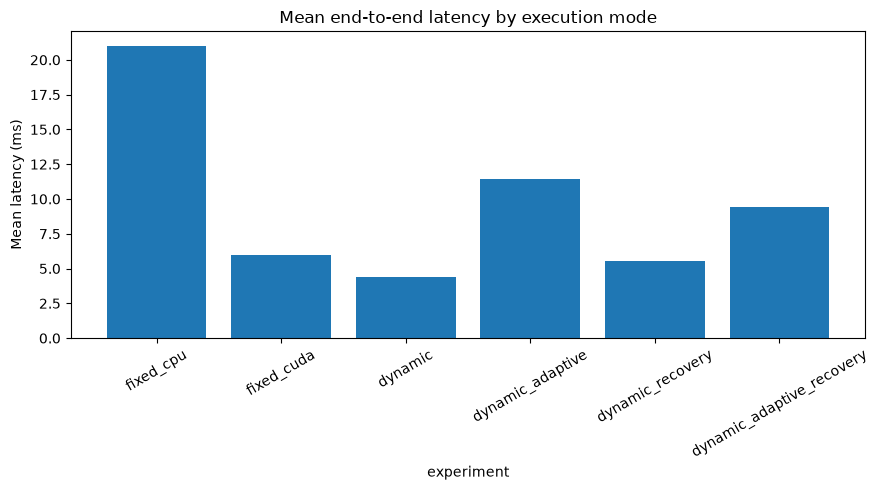

In [43]:
fig = plot_latency_comparison(
    pooled_summary,
    metric="mean_ms",
    title="Mean end-to-end latency by execution mode",
)
display(fig)

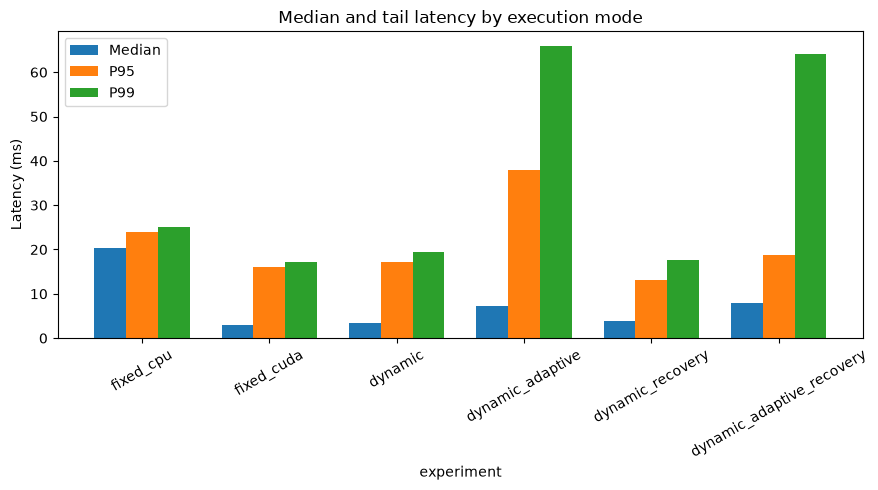

In [44]:
fig = plot_tail_latency(
    pooled_summary,
    title="Median and tail latency by execution mode",
)
display(fig)

### Latency distributions

The first boxplot shows all conditions. The second is the **FlexOn-only** view; this avoids visually compressing the 1–7 ms distributions because the CPU baseline is much slower.


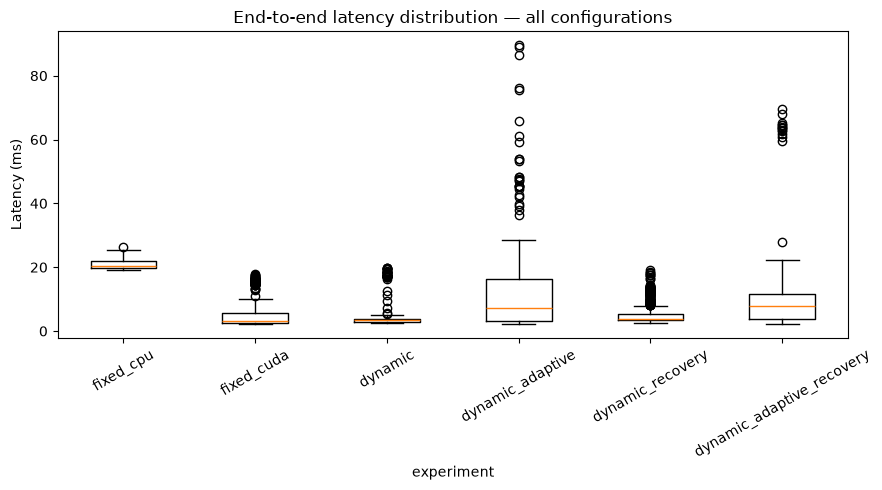

In [45]:
samples = latency_samples_dataframe(records)
fig = plot_latency_distribution(
    samples,
    exclude_groups=[],
    title="End-to-end latency distribution — all configurations",
)
display(fig)

### Percentile view

Percentiles are retained because mean latency alone can hide rare tail spikes. The focused view makes the P90/P95/P99 behavior of the FlexOn configurations easier to inspect.


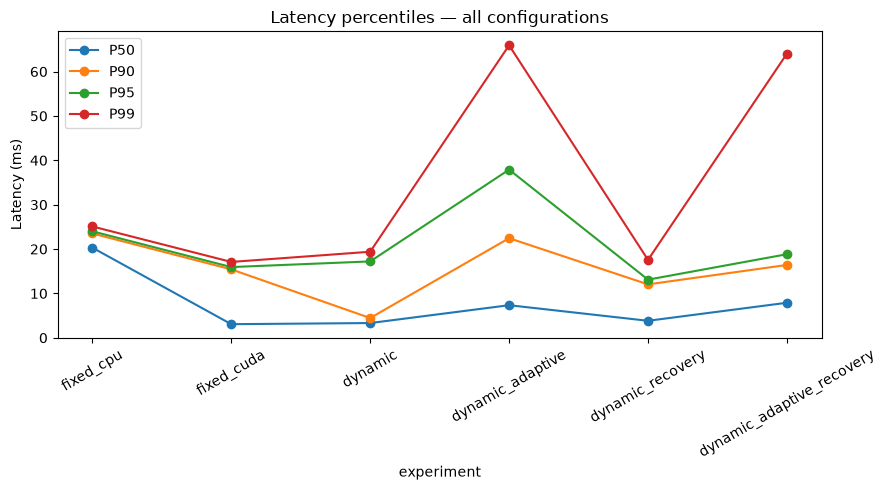

In [46]:
fig = plot_latency_percentiles(
    pooled_summary,
    title="Latency percentiles — all configurations",
)
display(fig)

### Runtime-path diagnostics

These plots are **diagnostics, not latency metrics**. They verify that the intended FlexOn mechanisms were exercised. Segment execution counts are normalized as executions per measured run; adaptive level changes are shown separately.


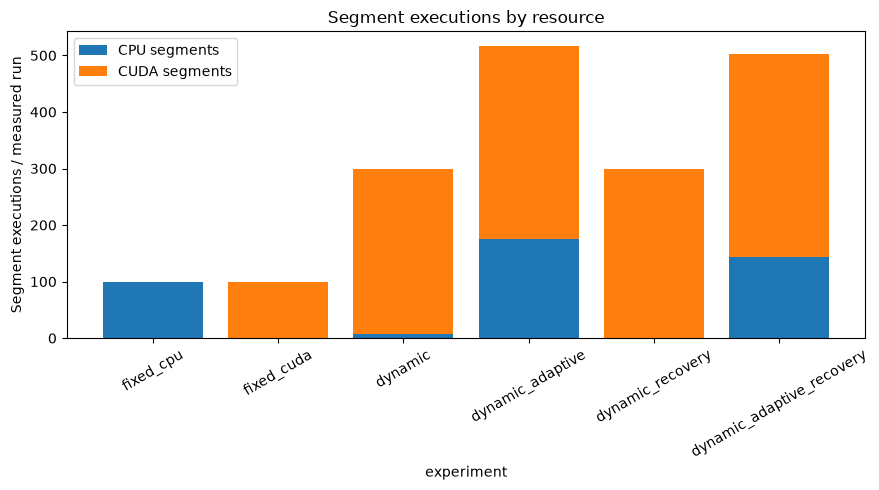

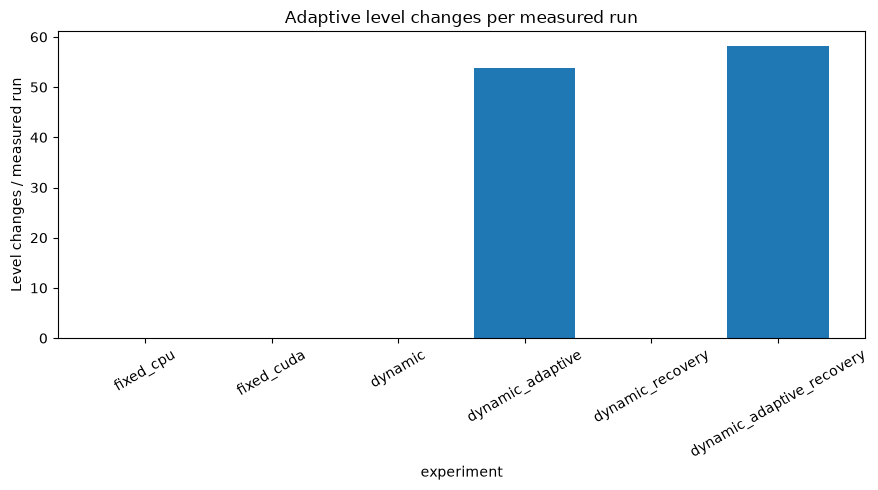

In [47]:
fig = plot_resource_execution_breakdown(
    diagnostics_df,
    title="Segment executions by resource",
)
display(fig)

fig = plot_level_changes(
    diagnostics_df,
    title="Adaptive level changes per measured run",
)
display(fig)

### Diagnostic interpretation

- `total_segment_executions` depends on the segmentation level, so it should not be expected to equal the number of measured iterations.
- `avg_segments_per_iteration` makes different segmentation granularities directly comparable.
- `adaptive_decisions` counts scheduler decisions; `level_changes` counts decisions that actually changed the selected level.
- Recovery counts can legitimately be zero in a no-contention environment because recovery is conditional rather than unconditional.
- Large but rare latency samples should be retained unless there is evidence of an instrumentation error.


## Persist experiment results

The raw measured samples, repetition-level summary, pooled summary, and runtime-path diagnostics are saved so the benchmark does not need to be rerun just to regenerate figures.


In [48]:
samples.to_csv(RESULTS_DIR / ENVIRONMENT_LABEL / "latency_samples.csv", index=False)
summary.to_csv(RESULTS_DIR / ENVIRONMENT_LABEL / "repetition_summary.csv", index=False)
pooled_summary.to_csv(RESULTS_DIR / ENVIRONMENT_LABEL / "pooled_summary.csv", index=False)
diagnostics_df.to_csv(RESULTS_DIR / ENVIRONMENT_LABEL / "diagnostics.csv", index=False)

print("Saved results under:", RESULTS_DIR / ENVIRONMENT_LABEL)

OSError: Cannot save file into a non-existent directory: '/home/aditya/Coding_23CSB0B30/Personal-Projects/FlexOn/results/cpu-25gpu-25'

## Experimental interpretation checklist

Before using the results in the report/presentation, verify:

- all six cases completed every repetition;
- warmup iterations were excluded consistently;
- fixed CPU and fixed CUDA use level 0 as the monolithic baselines;
- dynamic mode makes the expected resource decisions;
- adaptive modes emit level decisions and exhibit level changes when conditions warrant them;
- recovery modes record recovery attempts and winners when recovery is triggered;
- the same experiment notebook is used for idle and contention environments;
- contention configuration (kind/intensity) is recorded separately for each benchmark batch;
- rare latency outliers are retained and investigated rather than silently removed.
